# Sanity checks — aanwezigheid Toegepaste Informatica

Deze notebook controleert of de opvallend lage aanwezigheidsgraad plausibel is of mogelijk veroorzaakt wordt door problemen in de dataketen.

De belangrijkste vragen zijn:

1. Wat is de **grain** van `FactLecture`: één rij per les, of één rij per combinatie van les en subgroep?
2. Zijn er echte dubbele rijen of dubbele subgroepen?
3. Kloppen `AttendanceRate`, `UserCount` en `TotalStudents` wiskundig met elkaar?
4. Wordt `UserCount` bij een les met meerdere subgroepen herhaald?
5. Wordt `TotalStudents` mogelijk dubbel geteld?
6. Zijn de lage percentages geconcentreerd bij bepaalde subgroepen, lokalen, periodes of recordtypes?
7. Verandert het gemiddelde sterk wanneer we op **unieke lessen** in plaats van factrijen rekenen?

> Deze notebook corrigeert de data nog niet automatisch. Ze brengt eerst de mogelijke oorzaken en verdachte records in kaart.


In [25]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Data ophalen

We halen dezelfde PBA-TIN-periode op als in de EDA, maar nemen extra sleutels en lokaalgegevens mee.  
Een belangrijk detail uit het sterschema is dat `LectureID` en `SubgroupKey` samen mogelijk de grain van `FactLecture` bepalen.


In [26]:
server = "localhost\\MSSQLSERVER2019"
database = "DEP2"
driver = "ODBC Driver 17 for SQL Server"

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    f"?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

query = '''
SELECT
    fl.LectureID,
    fl.DateKey,
    fl.FromTimeKey,
    fl.UntilTimeKey,
    fl.ClassKey,
    fl.SubgroupKey,
    fl.RoomKey,
    fl.ActivityKey,
    fl.UserCount,
    fl.TotalStudents,
    fl.AttendanceRate,

    d.FullDate,
    d.NameDayDutch,
    d.NumberSemester,
    tf.Hour AS FromHour,
    tf.Minutes AS FromMinutes,
    tu.Hour AS UntilHour,
    tu.Minutes AS UntilMinutes,

    c.ClassName,
    c.ClassCode,
    c.ClassProgramStage,

    sg.SubgroupCode,
    sg.ProgramName,

    a.CanonicalActivity,
    a.ActivityDomain,
    a.ActivityGroup,
    a.IsCourse,
    a.IsExam,
    a.IsAcademicEvent,
    a.IsGuestLecture,
    a.IsMakeUp,
    a.IsPractical,
    a.IsPresentation,
    a.IsDigitalPossible,

    r.Building,
    r.Code AS RoomCode,
    r.RoomName,
    r.Category AS RoomCategory,
    r.Capacity AS RoomCapacity
FROM FactLecture fl
JOIN DimDate d ON fl.DateKey = d.DateKey
JOIN DimTime tf ON fl.FromTimeKey = tf.TimeKey
JOIN DimTime tu ON fl.UntilTimeKey = tu.TimeKey
JOIN DimClass c ON fl.ClassKey = c.ClassKey
JOIN DimSubgroup sg ON fl.SubgroupKey = sg.SubgroupKey
JOIN DimActivity a ON fl.ActivityKey = a.ActivityKey
JOIN DimRoom r ON fl.RoomKey = r.RoomKey
WHERE sg.ProgramName LIKE 'PBA-TIN%'
  AND fl.AttendanceRate IS NOT NULL
  AND fl.DateKey BETWEEN 20250925 AND 20260529
'''

df = pd.read_sql(query, engine)
df["FullDate"] = pd.to_datetime(df["FullDate"])

print(f"Aantal factrijen:       {len(df):,}")
print(f"Aantal unieke lessen:   {df['LectureID'].nunique():,}")
print(f"Aantal unieke subgroepen: {df['SubgroupKey'].nunique():,}")

df.head()


Aantal factrijen:       5,460
Aantal unieke lessen:   3,269
Aantal unieke subgroepen: 278


,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,AttendanceRate,FullDate,NameDayDutch,NumberSemester,FromHour,FromMinutes,UntilHour,UntilMinutes,ClassName,ClassCode,ClassProgramStage,SubgroupCode,ProgramName,CanonicalActivity,ActivityDomain,ActivityGroup,IsCourse,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,Building,RoomCode,RoomName,RoomCategory,RoomCapacity
0,381437,20250929,81500,101500,4007,5938924,2316,2,19,35,0.5429,2025-09-29,Maandag,1,8,15,10,15,Object-oriented Software Development I,193566,1.0000,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture,True,False,False,False,False,False,False,False,2,01.02.130.013,GSCHB.3.013,laptoplokaal,38
1,381438,20251006,81500,101500,4007,5938924,2323,2,17,35,0.4857,2025-10-06,Maandag,1,8,15,10,15,Object-oriented Software Development I,193566,1.0000,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture,True,False,False,False,False,False,False,False,2,01.02.110.011,GSCHB.1.011,laptoplokaal,42
2,381439,20251013,81500,101500,4007,5938924,2316,2,0,35,0.0000,2025-10-13,Maandag,1,8,15,10,15,Object-oriented Software Development I,193566,1.0000,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture,True,False,False,False,False,False,False,False,2,01.02.130.013,GSCHB.3.013,laptoplokaal,38
3,381440,20251020,81500,101500,4007,5938924,2316,2,18,35,0.5143,2025-10-20,Maandag,1,8,15,10,15,Object-oriented Software Development I,193566,1.0000,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture,True,False,False,False,False,False,False,False,2,01.02.130.013,GSCHB.3.013,laptoplokaal,38
4,381441,20251027,81500,101500,4007,5938924,2311,2,18,35,0.5143,2025-10-27,Maandag,1,8,15,10,15,Object-oriented Software Development I,193566,1.0000,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture,True,False,False,False,False,False,False,False,2,01.02.140.012,GSCHB.4.012,laptoplokaal,40


## 2. Grain en duplicaten controleren

Eerst bepalen we wat één rij precies voorstelt.

- Meerdere rijen met dezelfde `LectureID` kunnen legitiem zijn wanneer meerdere subgroepen dezelfde reservatie volgen.
- Meerdere rijen met dezelfde combinatie `LectureID + SubgroupKey` zijn veel verdachter.
- Exact identieke rijen zijn vrijwel zeker duplicaten.


In [27]:
rows_per_lecture = df.groupby("LectureID").size()

grain_summary = pd.Series({
    "Factrijen": len(df),
    "Unieke LectureID's": df["LectureID"].nunique(),
    "Lessen met 1 factrij": (rows_per_lecture == 1).sum(),
    "Lessen met meerdere factrijen": (rows_per_lecture > 1).sum(),
    "Maximum factrijen voor één LectureID": rows_per_lecture.max(),
    "Gemiddeld aantal factrijen per LectureID": rows_per_lecture.mean(),
})

grain_summary


Factrijen                                  5,460.0000
Unieke LectureID's                         3,269.0000
Lessen met 1 factrij                       2,268.0000
Lessen met meerdere factrijen              1,001.0000
Maximum factrijen voor één LectureID          11.0000
Gemiddeld aantal factrijen per LectureID       1.6702
dtype: float64

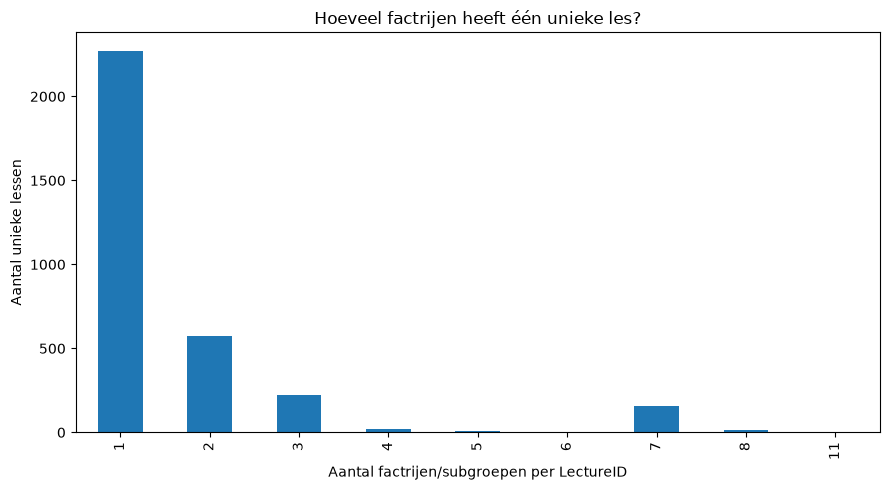

In [28]:
plt.figure(figsize=(9, 5))
rows_per_lecture.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Aantal factrijen/subgroepen per LectureID")
plt.ylabel("Aantal unieke lessen")
plt.title("Hoeveel factrijen heeft één unieke les?")
plt.tight_layout()
plt.show()


In [29]:
duplicate_composite = df[
    df.duplicated(subset=["LectureID", "SubgroupKey"], keep=False)
].sort_values(["LectureID", "SubgroupKey"])

exact_duplicates = df[df.duplicated(keep=False)].sort_values(
    ["LectureID", "SubgroupKey"]
)

print(f"Dubbele combinaties LectureID + SubgroupKey: {len(duplicate_composite):,} rijen")
print(f"Exact identieke dubbele rijen:               {len(exact_duplicates):,} rijen")

duplicate_composite.head(30)


Dubbele combinaties LectureID + SubgroupKey: 0 rijen
Exact identieke dubbele rijen:               0 rijen


,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,AttendanceRate,FullDate,NameDayDutch,NumberSemester,FromHour,FromMinutes,UntilHour,UntilMinutes,ClassName,ClassCode,ClassProgramStage,SubgroupCode,ProgramName,CanonicalActivity,ActivityDomain,ActivityGroup,IsCourse,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,Building,RoomCode,RoomName,RoomCategory,RoomCapacity


### Interpretatie

- **Geen dubbele `LectureID + SubgroupKey`**: meerdere factrijen per les zijn waarschijnlijk gewoon verschillende subgroepen.
- **Wel dubbele `LectureID + SubgroupKey`**: controleer de ETL of brondata; dezelfde subgroep lijkt meermaals aan dezelfde les gekoppeld.


## 3. Wiskundige consistentie van de aanwezigheidsvelden

We rekenen `AttendanceRate` opnieuw uit als `UserCount / TotalStudents` en vergelijken dit met de opgeslagen waarde.


In [30]:
df["RecalculatedAttendanceRate"] = np.where(
    df["TotalStudents"] > 0,
    df["UserCount"] / df["TotalStudents"],
    np.nan
)

df["AttendanceRateDifference"] = (
    df["AttendanceRate"] - df["RecalculatedAttendanceRate"]
).abs()

consistency_summary = pd.Series({
    "TotalStudents NULL": df["TotalStudents"].isna().sum(),
    "TotalStudents <= 0": (df["TotalStudents"].fillna(0) <= 0).sum(),
    "UserCount NULL": df["UserCount"].isna().sum(),
    "UserCount < 0": (df["UserCount"].fillna(0) < 0).sum(),
    "AttendanceRate < 0": (df["AttendanceRate"] < 0).sum(),
    "AttendanceRate > 1": (df["AttendanceRate"] > 1).sum(),
    "Afwijking opgeslagen/herberekend > 0.0001":
        (df["AttendanceRateDifference"] > 0.0001).sum(),
})

consistency_summary


TotalStudents NULL                           0
TotalStudents <= 0                           0
UserCount NULL                               0
UserCount < 0                                0
AttendanceRate < 0                           0
AttendanceRate > 1                           5
Afwijking opgeslagen/herberekend > 0.0001    0
dtype: int64

In [31]:
rate_mismatches = df[df["AttendanceRateDifference"] > 0.0001][[
    "LectureID", "SubgroupCode", "UserCount", "TotalStudents",
    "AttendanceRate", "RecalculatedAttendanceRate",
    "AttendanceRateDifference"
]].sort_values("AttendanceRateDifference", ascending=False)

rate_mismatches.head(30)


,LectureID,SubgroupCode,UserCount,TotalStudents,AttendanceRate,RecalculatedAttendanceRate,AttendanceRateDifference


## 4. Wordt `UserCount` herhaald over meerdere subgroepen?

Dit is een cruciale controle. Een access point telt aanwezige wifi-gebruikers op lokaal-/lesniveau.  
Wanneer één reservatie meerdere subgroepen bevat, kan hetzelfde `UserCount` in elke subgroeprij terechtkomen.

Dat is niet noodzakelijk fout in het DWH, maar betekent wel dat:

- factrijen niet onafhankelijk zijn;
- een gemiddelde over factrijen lessen met meerdere subgroepen zwaarder weegt;
- `UserCount` mogelijk niet per subgroep geïnterpreteerd mag worden.


In [32]:
lecture_structure = df.groupby("LectureID").agg(
    FactRows=("SubgroupKey", "size"),
    UniqueSubgroups=("SubgroupKey", "nunique"),
    UniqueUserCounts=("UserCount", "nunique"),
    MinUserCount=("UserCount", "min"),
    MaxUserCount=("UserCount", "max"),
    SumUserCount=("UserCount", "sum"),
    UniqueTotalStudentValues=("TotalStudents", "nunique"),
    SumTotalStudents=("TotalStudents", "sum"),
    MaxTotalStudents=("TotalStudents", "max"),
).reset_index()

multi = lecture_structure[lecture_structure["FactRows"] > 1].copy()

print(f"Unieke lessen met meerdere factrijen: {len(multi):,}")
print(
    "Daarvan met exact hetzelfde UserCount op alle factrijen: "
    f"{(multi['UniqueUserCounts'] == 1).sum():,} "
    f"({(multi['UniqueUserCounts'] == 1).mean():.1%})"
)

multi.sort_values(
    ["FactRows", "SumTotalStudents"],
    ascending=[False, False]
).head(30)


Unieke lessen met meerdere factrijen: 1,001
Daarvan met exact hetzelfde UserCount op alle factrijen: 134 (13.4%)


,LectureID,FactRows,UniqueSubgroups,UniqueUserCounts,MinUserCount,MaxUserCount,SumUserCount,UniqueTotalStudentValues,SumTotalStudents,MaxTotalStudents
3055,476148,11,11,1,0,0,0,8,195,28
3072,479883,8,8,5,0,25,85,7,135,36
464,385861,8,8,4,0,4,12,7,129,26
465,385862,8,8,5,0,4,16,7,129,26
466,385863,8,8,4,0,3,10,7,129,26
772,394377,8,8,8,2,25,106,7,119,28
773,394378,8,8,3,0,2,4,7,119,28
774,394379,8,8,1,0,0,0,7,119,28
775,394380,8,8,8,0,15,59,7,119,28
776,394381,8,8,7,2,24,97,7,119,28


In [33]:
repeated_usercount_examples = (
    df[df["LectureID"].isin(
        multi.loc[multi["UniqueUserCounts"] == 1, "LectureID"]
    )]
    .sort_values(["LectureID", "SubgroupCode"])
    [[
        "LectureID", "FullDate", "FromHour", "ClassName",
        "SubgroupCode", "UserCount", "TotalStudents", "AttendanceRate"
    ]]
)

repeated_usercount_examples.head(50)


,LectureID,FullDate,FromHour,ClassName,SubgroupCode,UserCount,TotalStudents,AttendanceRate
466,381665,2025-12-19,10,IT Fundamentals,PBA-TIN-TI/1A,0,34,0.0000
465,381665,2025-12-19,10,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,0,8,0.0000
467,381784,2025-09-26,15,IT Fundamentals,PBA-TIN-TI/1B,0,31,0.0000
468,381784,2025-09-26,15,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,0,8,0.0000
459,381786,2025-10-10,15,IT Fundamentals,PBA-TIN-TI/1B,0,31,0.0000
460,381786,2025-10-10,15,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,0,8,0.0000
463,381788,2025-10-24,15,IT Fundamentals,PBA-TIN-TI/1B,0,31,0.0000
464,381788,2025-10-24,15,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,0,8,0.0000
443,381796,2025-12-19,15,IT Fundamentals,PBA-TIN-TI/1B,0,31,0.0000
444,381796,2025-12-19,15,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,0,8,0.0000


### Waarop letten?

Voor een les met twee subgroepen kan dit bijvoorbeeld voorkomen:

| LectureID | Subgroep | UserCount | TotalStudents |
|---|---|---:|---:|
| X | A | 20 | 30 |
| X | B | 20 | 35 |

Dan is `UserCount = 20` waarschijnlijk het totale aantal gedetecteerde aanwezigen in het lokaal, niet twintig aanwezigen uit elke afzonderlijke subgroep.

De zinvolle aanwezigheid op **lesniveau** zou dan eerder `20 / (30 + 35)` zijn dan het gemiddelde van `20/30` en `20/35`.


## 5. Vergelijk factrijniveau met uniek lesniveau

We berekenen verschillende scenario's om te zien hoeveel de gekozen grain het globale gemiddelde beïnvloedt.

### Scenario A — huidige EDA
Gemiddelde van alle factrijen.

### Scenario B — unieke les, `max(UserCount) / sum(TotalStudents)`
Geschikt wanneer hetzelfde lokaalniveau-`UserCount` over subgroepen wordt herhaald.

### Scenario C — unieke les, `sum(UserCount) / sum(TotalStudents)`
Alleen geschikt wanneer `UserCount` werkelijk subgroepspecifiek is.

De notebook kiest niet automatisch welk scenario correct is; ze toont hoe groot het verschil is.


In [34]:
lecture_level = df.groupby("LectureID").agg(
    FullDate=("FullDate", "first"),
    ClassName=("ClassName", "first"),
    ActivityDomain=("ActivityDomain", "first"),
    FactRows=("SubgroupKey", "size"),
    UniqueSubgroups=("SubgroupKey", "nunique"),
    UserCountMax=("UserCount", "max"),
    UserCountSum=("UserCount", "sum"),
    UserCountNunique=("UserCount", "nunique"),
    TotalStudentsSum=("TotalStudents", "sum"),
    TotalStudentsMax=("TotalStudents", "max"),
).reset_index()

lecture_level["Rate_MaxUsers_Over_SumStudents"] = (
    lecture_level["UserCountMax"] / lecture_level["TotalStudentsSum"]
)

lecture_level["Rate_SumUsers_Over_SumStudents"] = (
    lecture_level["UserCountSum"] / lecture_level["TotalStudentsSum"]
)

comparison = pd.DataFrame({
    "Methode": [
        "Factrijniveau: gemiddelde opgeslagen AttendanceRate",
        "Unieke les: max(UserCount) / som(TotalStudents)",
        "Unieke les: som(UserCount) / som(TotalStudents)",
    ],
    "Gemiddelde": [
        df["AttendanceRate"].mean(),
        lecture_level["Rate_MaxUsers_Over_SumStudents"].mean(),
        lecture_level["Rate_SumUsers_Over_SumStudents"].mean(),
    ],
    "Mediaan": [
        df["AttendanceRate"].median(),
        lecture_level["Rate_MaxUsers_Over_SumStudents"].median(),
        lecture_level["Rate_SumUsers_Over_SumStudents"].median(),
    ],
})

comparison


,Methode,Gemiddelde,Mediaan
0,Factrijniveau: gemiddelde opgeslagen Attendanc...,0.2856,0.2500
1,Unieke les: max(UserCount) / som(TotalStudents),0.2729,0.2444
2,Unieke les: som(UserCount) / som(TotalStudents),0.3034,0.2941


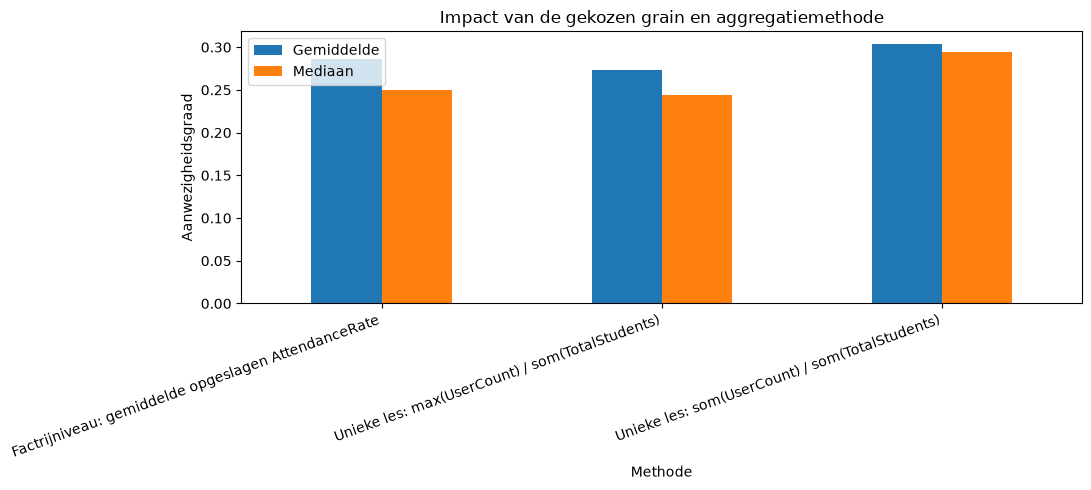

In [35]:
comparison.set_index("Methode")[["Gemiddelde", "Mediaan"]].plot(
    kind="bar", figsize=(11, 5)
)
plt.ylabel("Aanwezigheidsgraad")
plt.title("Impact van de gekozen grain en aggregatiemethode")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 6. Mogelijke overschatting van `TotalStudents`

Zonder een student-level bridge kunnen we niet rechtstreeks bewijzen dat één student dubbel geteld is.  
We kunnen wel verdachte patronen zoeken:

- exact dezelfde subgroep meermaals binnen één les;
- ongewoon grote `TotalStudents`;
- `TotalStudents` groter dan lokaalcapaciteit;
- sterke sprongen in grootte voor dezelfde subgroep;
- identieke groepsgroottes die binnen dezelfde les meerdere keren voorkomen.


In [36]:
student_count_summary = df["TotalStudents"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
student_count_summary


count   5,460.0000
mean       24.2282
std        11.6749
min         1.0000
1%          1.0000
5%          3.0000
25%        12.0000
50%        27.0000
75%        33.0000
95%        41.0000
99%        43.0000
max        60.0000
Name: TotalStudents, dtype: float64

In [37]:
room_capacity_checks = pd.Series({
    "Rijen met onbekende lokaalcapaciteit": df["RoomCapacity"].isna().sum(),
    "TotalStudents > RoomCapacity":
        (df["TotalStudents"] > df["RoomCapacity"]).sum(),
    "UserCount > RoomCapacity":
        (df["UserCount"] > df["RoomCapacity"]).sum(),
    "Som TotalStudents per les > RoomCapacity":
        (
            lecture_level["TotalStudentsSum"] >
            df.groupby("LectureID")["RoomCapacity"].first()
              .reindex(lecture_level["LectureID"]).to_numpy()
        ).sum(),
})

room_capacity_checks


Rijen met onbekende lokaalcapaciteit          0
TotalStudents > RoomCapacity                609
UserCount > RoomCapacity                      2
Som TotalStudents per les > RoomCapacity    980
dtype: int64

In [38]:
lecture_room_check = (
    df.groupby("LectureID")
      .agg(
          FullDate=("FullDate", "first"),
          ClassName=("ClassName", "first"),
          RoomCode=("RoomCode", "first"),
          RoomCapacity=("RoomCapacity", "first"),
          Subgroups=("SubgroupCode", lambda x: ", ".join(sorted(set(map(str, x))))),
          FactRows=("SubgroupKey", "size"),
          UserCount=("UserCount", "max"),
          SumTotalStudents=("TotalStudents", "sum"),
      )
      .reset_index()
)

suspicious_capacity = lecture_room_check[
    (lecture_room_check["SumTotalStudents"] > lecture_room_check["RoomCapacity"]) |
    (lecture_room_check["UserCount"] > lecture_room_check["RoomCapacity"])
].sort_values(
    ["SumTotalStudents", "UserCount"],
    ascending=False
)

suspicious_capacity.head(50)


,LectureID,FullDate,ClassName,RoomCode,RoomCapacity,Subgroups,FactRows,UserCount,SumTotalStudents
2220,424594,2026-03-04,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,32,209
2219,424593,2026-02-25,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,31,209
2222,424596,2026-03-18,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,29,209
2223,424597,2026-03-25,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,27,209
2232,424608,2026-02-25,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,27,209
2235,424611,2026-03-18,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,27,209
2233,424609,2026-03-04,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,26,209
2221,424595,2026-03-11,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,25,209
2224,424598,2026-04-01,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,25,209
2227,424603,2026-05-06,System Engineering Lab,01.02.140.037,72,"PBA-TIN-TI/1A, PBA-TIN-TI/1B, PBA-TIN-TI/1C, P...",7,25,209


> `TotalStudents > RoomCapacity` is niet automatisch een fout: een docent kan een te klein lokaal reserveren, capaciteit kan verouderd zijn, of meerdere parallelle groepen kunnen aan dezelfde reservatie gekoppeld zijn. Het is wel een goede shortlist voor handmatige controle.


## 7. Stabiliteit van groepsgroottes

Voor dezelfde `SubgroupCode` verwachten we doorgaans geen extreme schommelingen in `TotalStudents` binnen korte tijd.  
Sterke variatie kan wijzen op:

- verschillende combinaties van klasgroepen;
- wijzigingen in inschrijvingen;
- verkeerde joins;
- meerdere definities van dezelfde subgroepcode.


In [39]:
subgroup_stability = df.groupby("SubgroupCode").agg(
    Lessons=("LectureID", "nunique"),
    MinStudents=("TotalStudents", "min"),
    MedianStudents=("TotalStudents", "median"),
    MaxStudents=("TotalStudents", "max"),
    MeanStudents=("TotalStudents", "mean"),
    StdStudents=("TotalStudents", "std"),
    UniqueStudentCounts=("TotalStudents", "nunique"),
).reset_index()

subgroup_stability["MaxMinRatio"] = np.where(
    subgroup_stability["MinStudents"] > 0,
    subgroup_stability["MaxStudents"] / subgroup_stability["MinStudents"],
    np.nan
)

subgroup_stability.sort_values(
    ["MaxMinRatio", "UniqueStudentCounts"],
    ascending=False
).head(40)


,SubgroupCode,Lessons,MinStudents,MedianStudents,MaxStudents,MeanStudents,StdStudents,UniqueStudentCounts,MaxMinRatio
20,PBA-TIN-TI/3A2,45,1,20.0000,36,20.1333,11.7039,4,36.0000
24,PBA-TIN-TI/3B1,111,1,23.0000,28,23.8649,3.6791,7,28.0000
28,PBA-TIN-TI/3D,48,1,24.5000,26,20.3750,9.4994,3,26.0000
27,PBA-TIN-TI/3C2,95,2,35.0000,37,27.8421,9.3471,7,18.5000
19,PBA-TIN-TI/3A1,47,2,25.0000,35,23.4043,11.0270,5,17.5000
33,PBA-TIN-TI/VT/NET/S1,247,1,4.0000,10,5.1174,3.0667,6,10.0000
15,PBA-TIN-TI/2D,112,1,7.0000,10,5.6071,2.8738,4,10.0000
26,PBA-TIN-TI/3C1,51,5,36.0000,38,28.5294,10.1180,7,7.6000
34,PBA-TIN-TI/VT/NET/S2,221,2,11.0000,14,10.3077,3.2397,6,7.0000
12,PBA-TIN-TI/2B,155,4,9.0000,26,11.6707,7.5414,9,6.5000


In [40]:
# Detailweergave van de meest variabele subgroepen
variable_subgroups = subgroup_stability.query(
    "Lessons >= 3 and UniqueStudentCounts >= 3"
).sort_values("MaxMinRatio", ascending=False)["SubgroupCode"].head(10)

df[df["SubgroupCode"].isin(variable_subgroups)][[
    "FullDate", "LectureID", "ClassName", "SubgroupCode",
    "TotalStudents", "UserCount", "AttendanceRate"
]].sort_values(["SubgroupCode", "FullDate"]).head(100)


,FullDate,LectureID,ClassName,SubgroupCode,TotalStudents,UserCount,AttendanceRate
2855,2025-09-26,383318,Functional Analysis,PBA-TIN-TI/2B,7,0,0.0000
3128,2025-09-26,383370,Classic Computer Science Algorithms,PBA-TIN-TI/2B,9,0,0.0000
3495,2025-09-26,383344,Professional Communication,PBA-TIN-TI/2B,8,0,0.0000
2985,2025-09-29,383082,Relational Databases & Datawarehousing,PBA-TIN-TI/2B,11,7,0.6364
3630,2025-09-29,396093,Costing,PBA-TIN-TI/2B,4,0,0.0000
3752,2025-09-29,394377,The IT Professional,PBA-TIN-TI/2B,5,4,0.8000
3049,2025-09-30,394500,Relational Databases & Datawarehousing,PBA-TIN-TI/2B,11,2,0.1818
3311,2025-09-30,395497,Classic Computer Science Algorithms,PBA-TIN-TI/2B,9,5,0.5556
3875,2025-09-30,395085,Web Services,PBA-TIN-TI/2B,6,2,0.3333
2857,2025-10-03,383319,Functional Analysis,PBA-TIN-TI/2B,7,0,0.0000


## 8. Zijn lage aanwezigheden gekoppeld aan een technisch patroon?

Als zeer lage percentages vooral voorkomen in één lokaal, één periode, één subgroep of bij meerdere subgroepen per les, kan dat wijzen op een meet- of aggregatieprobleem in plaats van werkelijk studentengedrag.


In [41]:
df["AttendanceBand"] = pd.cut(
    df["AttendanceRate"],
    bins=[-np.inf, 0.05, 0.20, 0.50, 0.90, np.inf],
    labels=["<= 5%", "5–20%", "20–50%", "50–90%", "> 90%"]
)

df["MultipleFactRowsForLecture"] = df["LectureID"].map(rows_per_lecture) > 1

low_pattern_summary = pd.DataFrame({
    "Alle rijen": df.describe(include="all").loc["count"],
})

print("Aandeel <20% bij lessen met één factrij:")
print(
    (df.loc[~df["MultipleFactRowsForLecture"], "AttendanceRate"] < 0.20).mean()
)

print("\nAandeel <20% bij lessen met meerdere factrijen:")
print(
    (df.loc[df["MultipleFactRowsForLecture"], "AttendanceRate"] < 0.20).mean()
)


Aandeel <20% bij lessen met één factrij:
0.38492063492063494

Aandeel <20% bij lessen met meerdere factrijen:
0.49122807017543857


In [42]:
def low_attendance_profile(column, min_count=20, top_n=20):
    result = (
        df.groupby(column, dropna=False)
          .agg(
              Rows=("LectureID", "size"),
              UniqueLectures=("LectureID", "nunique"),
              MeanAttendance=("AttendanceRate", "mean"),
              MedianAttendance=("AttendanceRate", "median"),
              ShareBelow20=("AttendanceRate", lambda x: (x < 0.20).mean()),
          )
          .query("Rows >= @min_count")
          .sort_values(["ShareBelow20", "Rows"], ascending=[False, False])
    )
    return result.head(top_n)

print("Per lokaal:")
display(low_attendance_profile("RoomCode"))

print("\nPer subgroep:")
display(low_attendance_profile("SubgroupCode"))

print("\nPer lesvorm:")
display(low_attendance_profile("ActivityDomain", min_count=5))

print("\nPer semester:")
display(low_attendance_profile("NumberSemester", min_count=1))


Per lokaal:


,Rows,UniqueLectures,MeanAttendance,MedianAttendance,ShareBelow20
RoomCode,,,,,
01.02.120.009,192,85,0.2132,0.1111,0.5990
01.02.120.011,218,85,0.2235,0.1319,0.5780
01.02.130.028,175,98,0.2102,0.1154,0.5771
01.02.140.039,40,37,0.2721,0.1310,0.5750
01.02.100.010,63,8,0.3034,0.1250,0.5397
01.02.130.036,872,312,0.2567,0.1723,0.5298
01.02.110.036,231,123,0.2506,0.1714,0.5152
01.02.110.017,132,99,0.2408,0.1968,0.5000
01.02.110.029,105,76,0.2556,0.2500,0.4762



Per subgroep:


,Rows,UniqueLectures,MeanAttendance,MedianAttendance,ShareBelow20
SubgroupCode,,,,,
PBA-TIN-TI/3D,48,48,0.2271,0.0000,0.7292
PBA-TIN-TI/2D,112,112,0.1760,0.0000,0.7143
PBA-TIN-TI/3A2,45,45,0.2031,0.1000,0.6889
PBA-TIN-TI/3E,55,55,0.1299,0.0000,0.6545
PBA-TIN-TI/3B1,111,111,0.2416,0.1429,0.6036
PBA-TIN-TI/VT/PROG/S2,162,162,0.2057,0.0500,0.5988
PBA-TIN-TI/2A3,140,140,0.1884,0.1339,0.5857
PBA-TIN-TI/3C1,51,51,0.2335,0.1842,0.5490
PBA-TIN-TI/1B,314,314,0.2656,0.1852,0.5350



Per lesvorm:


,Rows,UniqueLectures,MeanAttendance,MedianAttendance,ShareBelow20
ActivityDomain,,,,,
Course,5433,3255,0.2848,0.2500,0.4478
Exam,27,14,0.4542,0.5000,0.2963



Per semester:


,Rows,UniqueLectures,MeanAttendance,MedianAttendance,ShareBelow20
NumberSemester,,,,,
2,3043,1728,0.2778,0.2258,0.4693
1,2417,1541,0.2954,0.2667,0.4191


## 9. Nulwaarden en extreem lage lessen inspecteren

Een `AttendanceRate` van nul kan echt zijn, maar ook betekenen dat:

- de wifi-data voor dat tijdstip ontbrak;
- het access point niet correct aan het lokaal gekoppeld was;
- de reservatie niet werkelijk doorging;
- studenten niet met het campusnetwerk verbonden waren.

Daarom verwijderen we nulwaarden niet automatisch, maar inspecteren we hun verdeling.


In [43]:
zero_lessons = df[df["AttendanceRate"] == 0].copy()

print(f"Aantal factrijen met 0% aanwezigheid: {len(zero_lessons):,}")
print(f"Aantal unieke lessen met minstens één 0%-rij: {zero_lessons['LectureID'].nunique():,}")
print(f"Aandeel van alle factrijen: {len(zero_lessons) / len(df):.1%}")

zero_lessons[[
    "LectureID", "FullDate", "FromHour", "ClassName",
    "SubgroupCode", "RoomCode", "UserCount",
    "TotalStudents", "AttendanceRate", "ActivityDomain"
]].sort_values(["FullDate", "LectureID"]).head(50)


Aantal factrijen met 0% aanwezigheid: 1,182
Aantal unieke lessen met minstens één 0%-rij: 799
Aandeel van alle factrijen: 21.6%


,LectureID,FullDate,FromHour,ClassName,SubgroupCode,RoomCode,UserCount,TotalStudents,AttendanceRate,ActivityDomain
270,381543,2025-09-25,13,Databases,PBA-TIN-TI/1A,01.02.130.029,0,35,0.0000,Course
305,381756,2025-09-25,9,Databases,PBA-TIN-TI/1B,01.02.130.029,0,28,0.0000,Course
3441,384046,2025-09-25,8,Classic Computer Science Algorithms,PBA-TIN2-TI/VT/NET/SEM1,01.02.130.026,0,3,0.0000,Course
3451,384046,2025-09-25,8,Classic Computer Science Algorithms,PBA-TIN-TI/2A3,01.02.130.026,0,16,0.0000,Course
3452,384046,2025-09-25,8,Classic Computer Science Algorithms,PBA-TIN-TI/2E2,01.02.130.026,0,25,0.0000,Course
4482,386185,2025-09-25,9,Windows Server II,PBA-TIN-TI/3B1,01.02.140.037,0,28,0.0000,Course
4471,386198,2025-09-25,10,Windows Server II,PBA-TIN-TI/3B1,01.02.140.037,0,28,0.0000,Course
3665,394601,2025-09-25,10,Costing,PBA-TIN-TI/VT/NET/S1,01.02.130.015,0,9,0.0000,Course
2926,395451,2025-09-25,13,Functional Analysis,PBA-TIN-TI/2C1,01.02.130.013,0,28,0.0000,Course
2927,395451,2025-09-25,13,Functional Analysis,PBA-TIN-TI/2D,01.02.130.013,0,7,0.0000,Course


In [44]:
# Controleer of nulmetingen geconcentreerd zijn per lokaal of datum.
zero_by_room = (
    df.assign(IsZero=df["AttendanceRate"].eq(0))
      .groupby("RoomCode")
      .agg(
          Rows=("LectureID", "size"),
          ZeroRows=("IsZero", "sum"),
          ZeroShare=("IsZero", "mean"),
      )
      .query("Rows >= 20")
      .sort_values("ZeroShare", ascending=False)
)

zero_by_date = (
    df.assign(IsZero=df["AttendanceRate"].eq(0))
      .groupby("FullDate")
      .agg(
          Rows=("LectureID", "size"),
          ZeroRows=("IsZero", "sum"),
          ZeroShare=("IsZero", "mean"),
      )
      .query("Rows >= 5")
      .sort_values("ZeroShare", ascending=False)
)

display(zero_by_room.head(20))
display(zero_by_date.head(20))


,Rows,ZeroRows,ZeroShare
RoomCode,,,
01.02.130.028,175,72,0.4114
01.02.120.009,192,77,0.4010
01.02.100.010,63,22,0.3492
01.02.110.029,105,34,0.3238
01.02.140.029,114,33,0.2895
01.02.120.008,58,15,0.2586
01.02.140.027,104,26,0.2500
01.02.130.012,165,41,0.2485
01.02.130.036,872,212,0.2431


,Rows,ZeroRows,ZeroShare
FullDate,,,
2025-10-13,43,43,1.0000
2025-12-19,31,27,0.8710
2026-03-16,42,31,0.7381
2025-12-17,19,14,0.7368
2025-12-18,26,18,0.6923
2026-05-22,62,41,0.6613
2026-05-19,36,22,0.6111
2026-05-18,44,23,0.5227
2025-10-03,36,17,0.4722


## 10. Handmatige steekproeven

Automatische checks kunnen een joinprobleem signaleren, maar de definitieve validatie gebeurt best met enkele concrete lessen die je zelf kent of die in TimeEdit gecontroleerd kunnen worden.

De cellen hieronder maken drie steekproeven:

1. willekeurige unieke lessen;
2. lessen met zeer lage aanwezigheid;
3. lessen met meerdere subgroepen of verdachte capaciteit.


In [45]:
def lecture_details(lecture_ids):
    columns = [
        "LectureID", "FullDate", "FromHour", "UntilHour",
        "ClassName", "SubgroupCode", "RoomCode", "RoomCapacity",
        "ActivityDomain", "UserCount", "TotalStudents", "AttendanceRate"
    ]
    return (
        df[df["LectureID"].isin(lecture_ids)][columns]
        .sort_values(["LectureID", "SubgroupCode"])
    )

random_lecture_ids = (
    df["LectureID"].drop_duplicates().sample(
        n=min(10, df["LectureID"].nunique()),
        random_state=42
    )
)

lecture_details(random_lecture_ids)


,LectureID,FullDate,FromHour,UntilHour,ClassName,SubgroupCode,RoomCode,RoomCapacity,ActivityDomain,UserCount,TotalStudents,AttendanceRate
203,381730,2025-11-05,9,12,Object-oriented Software Development I,PBA-TIN-TI/1B,01.02.130.026,25,Course,19,32,0.5938
291,381766,2025-12-04,9,12,Databases,PBA-TIN-TI/1B,01.02.130.029,59,Course,10,28,0.3571
134,382846,2025-11-07,10,12,Object-oriented Software Development I,PBA-TIN-TI/1H,01.02.130.036,69,Course,20,32,0.6250
425,382872,2025-10-31,13,15,IT Fundamentals,PBA-TIN-TI/1H,01.02.110.017,110,Course,6,33,0.1818
500,396033,2025-09-30,13,15,Cybersecurity,PBA-TIN-TI/1F,01.02.130.015,44,Course,15,37,0.4054
1469,423487,2026-05-07,8,10,Business & Management,PBA-TIN-TI/1D,01.02.130.013,38,Course,11,28,0.3929
1468,423487,2026-05-07,8,10,Business & Management,PBA-TIN-TI/VT/NET/S2,01.02.130.013,38,Course,1,9,0.1111
1700,424730,2026-04-24,8,10,Software Development Project I,PBA-TIN-TI/1A,01.02.130.036,69,Course,6,38,0.1579
1708,424730,2026-04-24,8,10,Software Development Project I,PBA-TIN-TI/1B,01.02.130.036,69,Course,3,27,0.1111
1709,424730,2026-04-24,8,10,Software Development Project I,PBA-TIN-TI/1C,01.02.130.036,69,Course,11,33,0.3333


In [46]:
very_low_ids = (
    lecture_level.nsmallest(10, "Rate_MaxUsers_Over_SumStudents")["LectureID"]
)
lecture_details(very_low_ids)


,LectureID,FullDate,FromHour,UntilHour,ClassName,SubgroupCode,RoomCode,RoomCapacity,ActivityDomain,UserCount,TotalStudents,AttendanceRate
2,381439,2025-10-13,8,10,Object-oriented Software Development I,PBA-TIN-TI/1A,01.02.130.013,38,Course,0,35,0.0000
220,381448,2025-12-15,8,10,Object-oriented Software Development I,PBA-TIN-TI/1A,01.02.130.029,59,Course,0,35,0.0000
270,381543,2025-09-25,13,16,Databases,PBA-TIN-TI/1A,01.02.130.029,59,Course,0,35,0.0000
271,381544,2025-10-02,13,16,Databases,PBA-TIN-TI/1A,01.02.130.029,59,Course,0,35,0.0000
272,381545,2025-10-09,13,16,Databases,PBA-TIN-TI/1A,01.02.130.029,59,Course,0,35,0.0000
224,381641,2025-10-13,10,12,Software Analysis,PBA-TIN-TI/1A,01.02.120.008,41,Course,0,31,0.0000
268,381650,2025-12-15,10,12,Software Analysis,PBA-TIN-TI/1A,01.02.120.008,41,Course,0,31,0.0000
466,381665,2025-12-19,10,12,IT Fundamentals,PBA-TIN-TI/1A,01.02.110.017,110,Course,0,34,0.0000
465,381665,2025-12-19,10,12,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,01.02.110.017,110,Course,0,8,0.0000
197,381736,2025-12-17,9,12,Object-oriented Software Development I,PBA-TIN-TI/1B,01.02.130.026,25,Course,0,32,0.0000


In [47]:
suspicious_ids = (
    suspicious_capacity["LectureID"].head(10)
    if len(suspicious_capacity) > 0
    else multi.sort_values("FactRows", ascending=False)["LectureID"].head(10)
)

lecture_details(suspicious_ids)


,LectureID,FullDate,FromHour,UntilHour,ClassName,SubgroupCode,RoomCode,RoomCapacity,ActivityDomain,UserCount,TotalStudents,AttendanceRate
2638,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1A,01.02.140.037,72,Course,25,32,0.7812
2635,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1B,01.02.140.037,72,Course,19,27,0.7037
2636,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1C,01.02.140.037,72,Course,27,33,0.8182
2627,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1D,01.02.140.037,72,Course,13,28,0.4643
2628,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1E,01.02.140.037,72,Course,8,27,0.2963
2629,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1F,01.02.140.037,72,Course,31,35,0.8857
2637,424593,2026-02-25,8,10,System Engineering Lab,PBA-TIN-TI/1G,01.02.140.037,72,Course,17,27,0.6296
2621,424594,2026-03-04,8,10,System Engineering Lab,PBA-TIN-TI/1A,01.02.140.037,72,Course,21,32,0.6562
2630,424594,2026-03-04,8,10,System Engineering Lab,PBA-TIN-TI/1B,01.02.140.037,72,Course,19,27,0.7037
2631,424594,2026-03-04,8,10,System Engineering Lab,PBA-TIN-TI/1C,01.02.140.037,72,Course,25,33,0.7576


## 11. Automatische samenvatting van de controles

Deze samenvatting is geen definitief oordeel, maar helpt bepalen waar je verder moet zoeken.


In [48]:
checks = pd.DataFrame([
    {
        "Controle": "Exact identieke factrijen",
        "VerdachteRecords": len(exact_duplicates),
        "Status": "OK" if len(exact_duplicates) == 0 else "NAKIJKEN",
        "Interpretatie": "Exacte duplicaten horen normaal niet voor te komen."
    },
    {
        "Controle": "Dubbele LectureID + SubgroupKey",
        "VerdachteRecords": len(duplicate_composite),
        "Status": "OK" if len(duplicate_composite) == 0 else "NAKIJKEN",
        "Interpretatie": "Kan wijzen op dubbele koppelingen of ETL-dubbels."
    },
    {
        "Controle": "AttendanceRate wijkt af van UserCount / TotalStudents",
        "VerdachteRecords": int((df["AttendanceRateDifference"] > 0.0001).sum()),
        "Status": "OK" if (df["AttendanceRateDifference"] > 0.0001).sum() == 0 else "NAKIJKEN",
        "Interpretatie": "De opgeslagen target moet wiskundig consistent zijn."
    },
    {
        "Controle": "Lessen met meerdere rijen en herhaald UserCount",
        "VerdachteRecords": int((multi["UniqueUserCounts"] == 1).sum()),
        "Status": "INTERPRETEREN",
        "Interpretatie": "Waarschijnlijk lokaalniveau-telling; analyse best op unieke les."
    },
    {
        "Controle": "TotalStudents per unieke les groter dan lokaalcapaciteit",
        "VerdachteRecords": len(suspicious_capacity),
        "Status": "INTERPRETEREN" if len(suspicious_capacity) else "OK",
        "Interpretatie": "Kan overschatting, gedeelde reservatie of te klein lokaal zijn."
    },
    {
        "Controle": "AttendanceRate > 100%",
        "VerdachteRecords": int((df["AttendanceRate"] > 1).sum()),
        "Status": "INTERPRETEREN" if (df["AttendanceRate"] > 1).sum() else "OK",
        "Interpretatie": "Mogelijk wifi-spillover, gasten of te kleine noemer."
    },
])

checks


,Controle,VerdachteRecords,Status,Interpretatie
0,Exact identieke factrijen,0,OK,Exacte duplicaten horen normaal niet voor te k...
1,Dubbele LectureID + SubgroupKey,0,OK,Kan wijzen op dubbele koppelingen of ETL-dubbels.
2,AttendanceRate wijkt af van UserCount / TotalS...,0,OK,De opgeslagen target moet wiskundig consistent...
3,Lessen met meerdere rijen en herhaald UserCount,134,INTERPRETEREN,Waarschijnlijk lokaalniveau-telling; analyse b...
4,TotalStudents per unieke les groter dan lokaal...,980,INTERPRETEREN,"Kan overschatting, gedeelde reservatie of te k..."
5,AttendanceRate > 100%,5,INTERPRETEREN,"Mogelijk wifi-spillover, gasten of te kleine n..."


## 12. Beslisboom voor de volgende stap

### Situatie A — `LectureID + SubgroupKey` bevat duplicaten
Ga terug naar de ETL of bronkoppeling. De noemer kan door dubbele klasgroeprecords opgeblazen zijn.

### Situatie B — meerdere subgroepen per les en hetzelfde `UserCount`
Behandel `FactLecture` niet als één onafhankelijke observatie per rij.  
Maak voor EDA en ML eerst één record per unieke `LectureID`, met een onderbouwde aggregatieregel.

### Situatie C — `TotalStudents` is systematisch groter dan bekende groepsgroottes
Controleer hoe `TotalStudents` wordt opgebouwd vanuit klasgroep-/studentendata. Gebruik bij voorkeur `COUNT(DISTINCT StudentId)` op de bron of bridge.

### Situatie D — veel nulmetingen clusteren per lokaal of datum
Onderzoek wifi-dekking, ontbrekende parquetbestanden, access-pointmapping en geannuleerde reservaties.

### Situatie E — de technische controles zijn grotendeels schoon
Dan kan de lage aanwezigheid reëel zijn, al blijft wifi-aanwezigheid een proxy voor fysieke aanwezigheid. Documenteer dat expliciet als beperking.


## Optionele broncontrole op studentniveau

Het getoonde sterschema bevat geen student- of bridge-tabel. Wanneer zo'n tabel wel in de staginglaag of bron aanwezig is, is de beste controle:

```sql
SELECT
    LectureID,
    COUNT(*) AS LinkedStudentRows,
    COUNT(DISTINCT StudentId) AS DistinctStudents
FROM <lecture_student_bridge_or_source>
GROUP BY LectureID
HAVING COUNT(*) <> COUNT(DISTINCT StudentId);
```

Vergelijk daarna `COUNT(DISTINCT StudentId)` met `FactLecture.TotalStudents`.

Deze controle kan pas ingevuld worden zodra de exacte tabel- en kolomnamen bekend zijn.
